<a href="https://colab.research.google.com/github/ayyanark1212-max/proj-agriii/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ===============================
# 1. Imports
# ===============================
import numpy as np
import pandas as pd
import time
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Handle missing numeric values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

FEATURES = ['N','P','K','pH','Temp(°C)','Humidity(%)','Moisture(%)','Rainfall(cm)']
TARGET = "Crop"

X = df[FEATURES]
y = df[TARGET]

# ===============================
# 3. Encode + Scale
# ===============================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(le, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

# ===============================
# 4. Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=SEED
)

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=SEED
)

cb = CatBoostClassifier(
    iterations=700,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=0
)

models = {
    "RandomForest": rf,
    "GradientBoosting": gb,
    "CatBoost": cb
}

In [7]:
def evaluate_model(name, model):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring="accuracy")

    model.fit(X_train, y_train)

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    return {
        "name": name,
        "model": model,
        "cv_mean": np.mean(cv_scores),
        "cv_std": np.std(cv_scores),
        "test_acc": acc,
        "test_f1": f1,
        "inference_time": inference_time,
        "predictions": y_pred
    }

In [8]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    results.append(evaluate_model(name, model))

Training RandomForest...
Training GradientBoosting...
Training CatBoost...


In [9]:
stack_model = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("cb", cb)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba",
    n_jobs=-1
)

results.append(evaluate_model("Stacking(RF+GB+CB)", stack_model))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [10]:
def agent_select_best(results, latency_penalty=0.0):
    scored_models = []

    for r in results:
        score = r["cv_mean"] - latency_penalty * r["inference_time"]
        scored_models.append((score, r["test_f1"], r))

    scored_models.sort(key=lambda x: (x[0], x[1]), reverse=True)

    return scored_models[0][2], scored_models

In [11]:
best_model_info, ranking = agent_select_best(results, latency_penalty=0.0)

print("\n===== MODEL RANKING =====")
for score, f1, r in ranking:
    print(f"{r['name']} | CV={r['cv_mean']:.4f} | Test={r['test_acc']:.4f}")

print("\n✅ Selected Model by Agent:", best_model_info["name"])

print("\nClassification Report:")
print(classification_report(
    y_test,
    best_model_info["predictions"],
    target_names=le.classes_
))


===== MODEL RANKING =====
RandomForest | CV=0.9625 | Test=0.9591
Stacking(RF+GB+CB) | CV=0.9614 | Test=0.9606
CatBoost | CV=0.9523 | Test=0.9606
GradientBoosting | CV=0.9489 | Test=0.9530

✅ Selected Model by Agent: RandomForest

Classification Report:
                  precision    recall  f1-score   support

       Aman Rice       0.82      0.90      0.86        30
       Aush Rice       0.93      0.87      0.90        30
            Bean       0.82      0.90      0.86        30
       Boro Rice       0.90      0.93      0.92        30
        Calabash       1.00      1.00      1.00        30
     Cauliflower       1.00      1.00      1.00        30
Colocasia leaves       1.00      0.90      0.95        30
            Corn       0.96      0.80      0.87        30
        Eggplant       1.00      0.97      0.98        30
            Jute       0.97      1.00      0.98        30
       Leafy Veg       0.93      0.93      0.93        30
        Oil crop       0.93      0.93      0.93  

In [12]:
joblib.dump(best_model_info["model"], "best_crop_model.pkl")
print("Best model saved as best_crop_model.pkl")

Best model saved as best_crop_model.pkl


In [13]:
def predict_crop(sample_dict):
    model = joblib.load("best_crop_model.pkl")
    scaler = joblib.load("scaler.pkl")
    le = joblib.load("label_encoder.pkl")

    x = np.array([[sample_dict[f] for f in FEATURES]])
    x_scaled = scaler.transform(x)

    pred = model.predict(x_scaled)[0]
    return le.inverse_transform([pred])[0]


sample = {
    'N': 90,
    'P': 42,
    'K': 43,
    'pH': 6.5,
    'Temp(°C)': 25,
    'Humidity(%)': 70,
    'Moisture(%)': 30,
    'Rainfall(cm)': 10
}

print("Predicted Crop:", predict_crop(sample))

Predicted Crop: Cauliflower


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


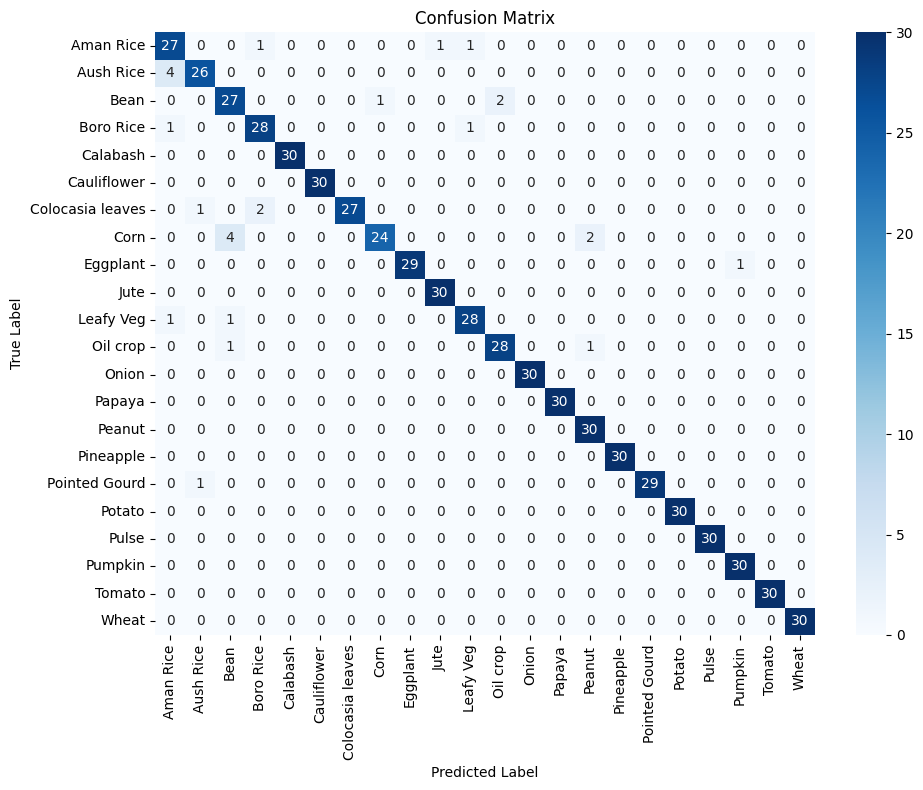

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test, label_encoder):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()

# Call this:
plot_confusion_matrix(best_model_info["model"], X_test, y_test, le)

In [15]:
from sklearn.metrics import accuracy_score, log_loss

def compute_metrics(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Log Loss
    train_loss = log_loss(y_train, y_train_proba)
    test_loss = log_loss(y_test, y_test_proba)

    return train_acc, test_acc, train_loss, test_loss

train_acc, test_acc, train_loss, test_loss = compute_metrics(
    best_model_info["model"], X_train, y_train, X_test, y_test
)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Train Log Loss:", train_loss)
print("Test Log Loss:", test_loss)

Train Accuracy: 1.0
Test Accuracy: 0.9590909090909091
Train Log Loss: 0.06689835041261206
Test Log Loss: 0.21742018013704778


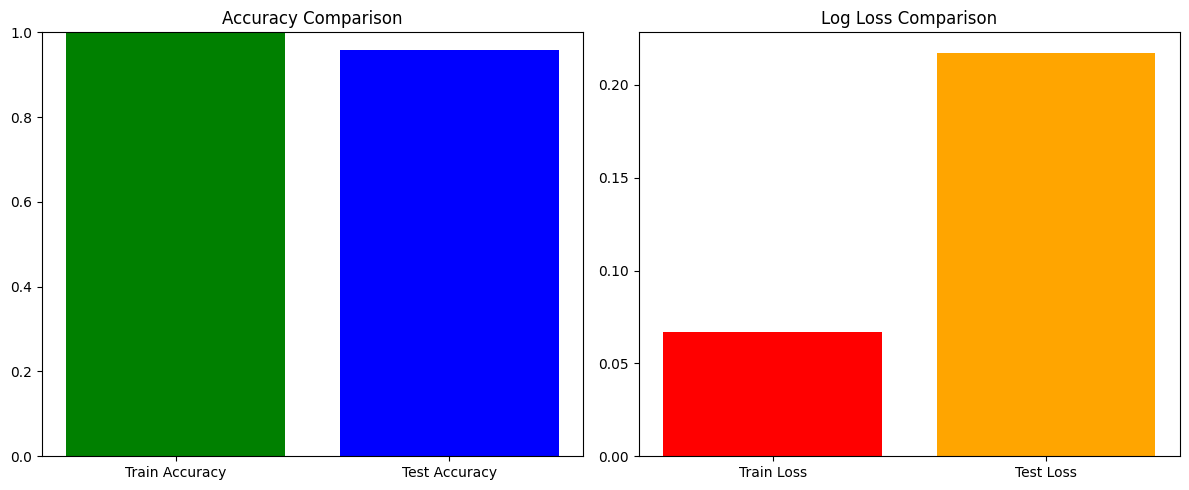

In [16]:
def plot_accuracy_loss(train_acc, test_acc, train_loss, test_loss):

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # Accuracy plot
    ax[0].bar(["Train Accuracy", "Test Accuracy"],
              [train_acc, test_acc],
              color=["green", "blue"])
    ax[0].set_ylim(0,1)
    ax[0].set_title("Accuracy Comparison")

    # Loss plot
    ax[1].bar(["Train Loss", "Test Loss"],
              [train_loss, test_loss],
              color=["red", "orange"])
    ax[1].set_title("Log Loss Comparison")

    plt.tight_layout()
    plt.savefig("accuracy_loss_plot.png", dpi=300)
    plt.show()

plot_accuracy_loss(train_acc, test_acc, train_loss, test_loss)

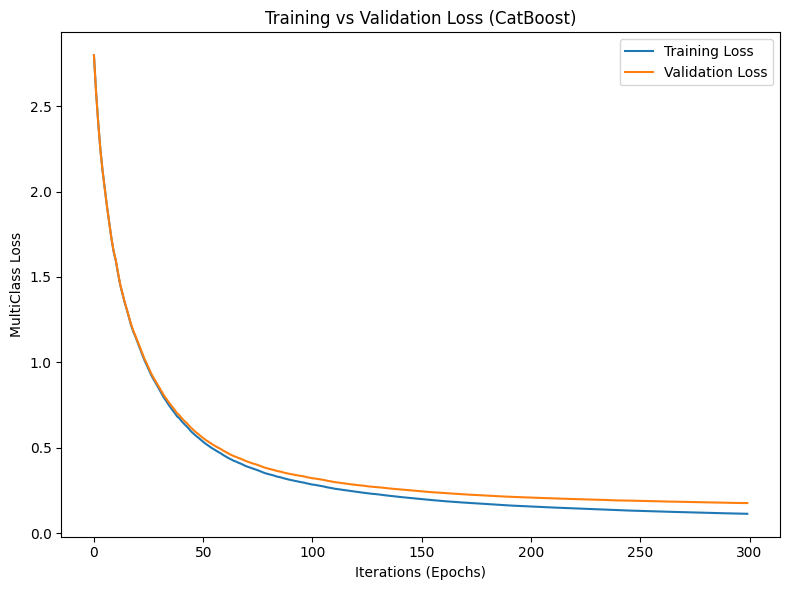

In [17]:
# Retrain CatBoost with evaluation set
cb_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    verbose=False,
    random_seed=42
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Extract loss per iteration
evals = cb_model.get_evals_result()

train_loss_curve = evals['learn']['MultiClass']
val_loss_curve = evals['validation']['MultiClass']

# Plot Epoch Curve
plt.figure(figsize=(8,6))
plt.plot(train_loss_curve, label="Training Loss")
plt.plot(val_loss_curve, label="Validation Loss")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("MultiClass Loss")
plt.title("Training vs Validation Loss (CatBoost)")
plt.legend()
plt.tight_layout()
plt.savefig("catboost_epoch_curve.png", dpi=300)
plt.show()

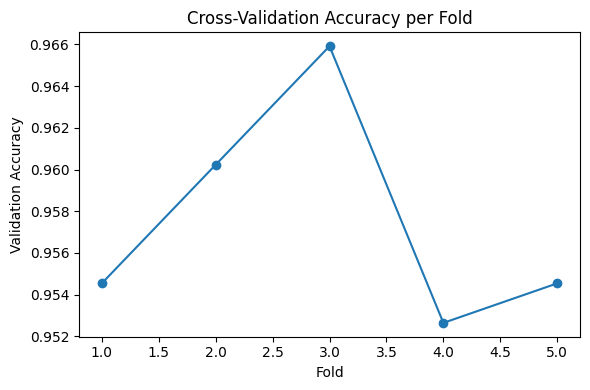

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model_info["model"],
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(6,4))
plt.plot(range(1,6), cv_scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("Cross-Validation Accuracy per Fold")
plt.tight_layout()
plt.savefig("cv_accuracy_curve.png", dpi=300)
plt.show()